In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install -q evaluate datasets transformers jiwer accelerate torchaudio librosa soundfile scikit-learn pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 124.5 MB/s eta 0:00:00


In [ ]:
import torch
from transformers import WhisperProcessor, WhisperForConditionalGeneration

device = "cuda" if torch.cuda.is_available() else "cpu"

model_name = "openai/whisper-small"

processor = WhisperProcessor.from_pretrained(model_name)
model = WhisperForConditionalGeneration.from_pretrained(model_name)

model.to(device)

print("Using device:", device)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:103: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


Loading weights:   0%|          | 0/479 [00:00<?, ?it/s]

Using device: cpu


In [ ]:
from transformers import WhisperForConditionalGeneration
import torch

device = torch.device("cuda")

model = WhisperForConditionalGeneration.from_pretrained(
    "openai/whisper-small"
)

model = model.to(device)

print("Model running on:", device)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/967M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/479 [00:00<?, ?it/s]

generation_config.json: 0.00B [00:00, ?B/s]

Model running on: cuda


In [ ]:
from pathlib import Path

audio_root = Path("/content/drive/MyDrive/spcs_whisper_project/data/SPCS/audio")
text_root = Path("/content/drive/MyDrive/spcs_whisper_project/data/SPCS/transcriptions")

wav_files = list(audio_root.rglob("*.wav"))
txt_files = list(text_root.rglob("*.txt"))

print("WAV files:", len(wav_files))
print("TXT files:", len(txt_files))

print("Sample audio:", wav_files[0])
print("Sample text:", txt_files[0])

print(txt_files[0].read_text(encoding="utf-8"))

WAV files: 12386
TXT files: 12388
Sample audio: /content/drive/MyDrive/spcs_whisper_project/data/SPCS/audio/018/018_Male_21_173.wav
Sample text: /content/drive/MyDrive/spcs_whisper_project/data/SPCS/transcriptions/020/020_Male_20_348.txt
hwetša di address tša batho


In [ ]:
from pathlib import Path

import pandas as pd

from sklearn.model_selection import train_test_split



ROOT = Path("/content/drive/MyDrive/spcs_whisper_project/data/SPCS")



audio_root = ROOT / "audio"

text_root = ROOT / "transcriptions"



rows = []



for wav_path in audio_root.rglob("*.wav"):

    rel_path = wav_path.relative_to(audio_root)

    txt_path = text_root / rel_path.with_suffix(".txt")



    if txt_path.exists():

        text = txt_path.read_text(encoding="utf-8").strip()



        rows.append({

            "audio": str(wav_path),

            "text": text

        })



df = pd.DataFrame(rows)



train_df, temp_df = train_test_split(

    df,

    test_size=0.2,

    random_state=42

)



valid_df, test_df = train_test_split(

    temp_df,

    test_size=0.5,

    random_state=42

)



manifest_dir = Path("/content/drive/MyDrive/spcs_whisper_project/manifests")

manifest_dir.mkdir(parents=True, exist_ok=True)



train_df.to_csv(manifest_dir / "train.csv", index=False)

valid_df.to_csv(manifest_dir / "valid.csv", index=False)

test_df.to_csv(manifest_dir / "test.csv", index=False)



print("Created manifests")

print("Train:", len(train_df))

print("Validation:", len(valid_df))

print("Test:", len(test_df))

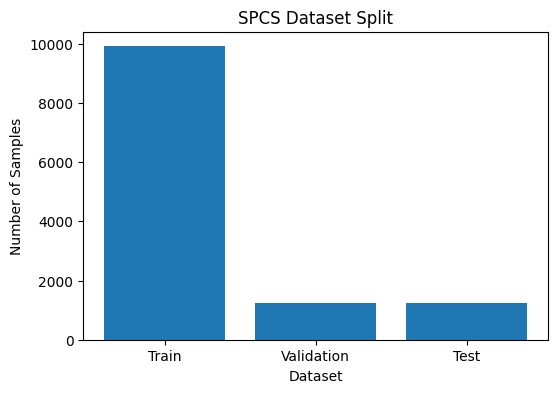

In [ ]:
import matplotlib.pyplot as plt

splits = ["Train", "Validation", "Test"]
counts = [9908, 1239, 1239]

plt.figure(figsize=(6,4))
plt.bar(splits, counts)

plt.title("SPCS Dataset Split")
plt.xlabel("Dataset")
plt.ylabel("Number of Samples")

plt.show()


Number of wav files: 12386
Using file: /content/drive/MyDrive/spcs_whisper_project/data/SPCS/audio/018/018_Male_21_173.wav


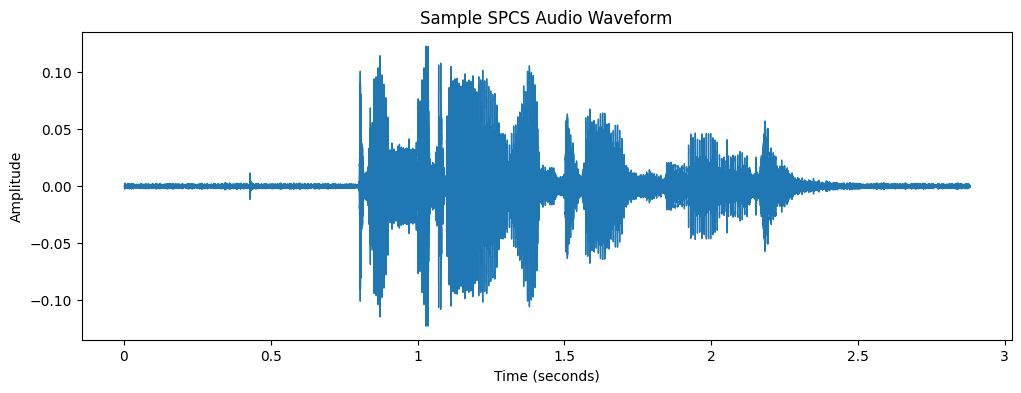

In [ ]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
from pathlib import Path

# =========================
# Find one WAV file
# =========================
audio_root = Path(
    "/content/drive/MyDrive/spcs_whisper_project/data/SPCS/audio"
)

wav_files = list(audio_root.rglob("*.wav"))

print("Number of wav files:", len(wav_files))

# Select first audio file
audio_path = str(wav_files[0])

print("Using file:", audio_path)

# =========================
# Load audio
# =========================
audio, sr = librosa.load(
    audio_path,
    sr=16000
)

# =========================
# Plot waveform
# =========================
plt.figure(figsize=(12,4))

librosa.display.waveshow(
    audio,
    sr=sr
)

plt.title("Sample SPCS Audio Waveform")

plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")

plt.show()

Total wav files: 12386
Using file: /content/drive/MyDrive/spcs_whisper_project/data/SPCS/audio/018/018_Male_21_173.wav
Audio duration (seconds): 2.88


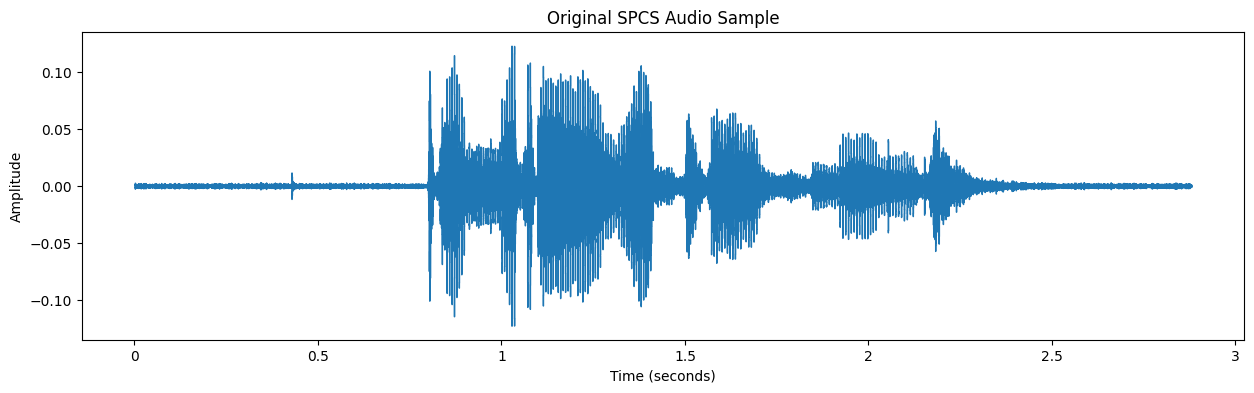

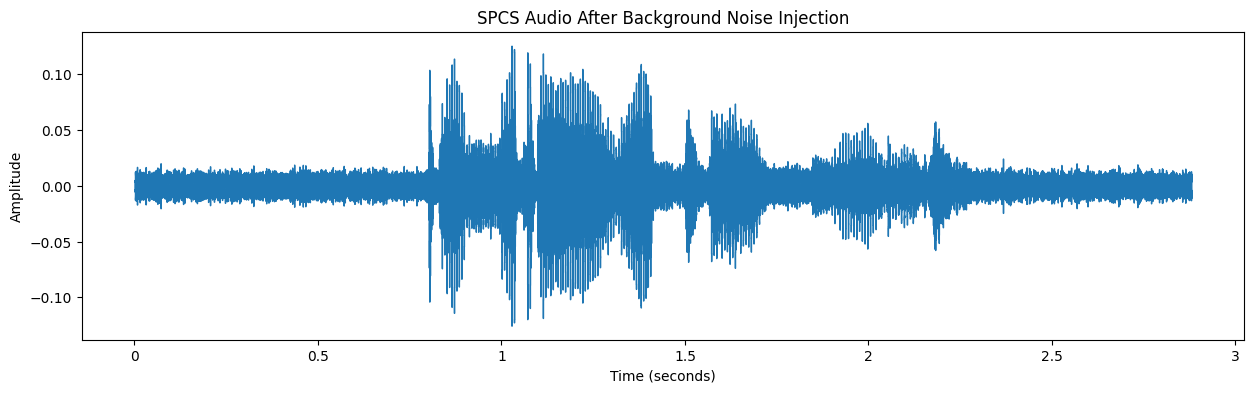

Saved noisy audio to:
/content/drive/MyDrive/spcs_whisper_project/results/noisy_sample.wav


In [ ]:
import numpy as np
import librosa
import librosa.display
import matplotlib.pyplot as plt
from pathlib import Path

# =========================================================
# LOAD FULL SAMPLE AUDIO
# =========================================================

audio_root = Path(
    "/content/drive/MyDrive/spcs_whisper_project/data/SPCS/audio"
)

wav_files = list(audio_root.rglob("*.wav"))

print("Total wav files:", len(wav_files))

# Select full sample
sample_file = wav_files[0]

print("Using file:", sample_file)

audio, sr = librosa.load(
    sample_file,
    sr=16000
)

print("Audio duration (seconds):", len(audio) / sr)

# =========================================================
# NOISE INJECTION
# =========================================================

def add_background_noise(audio_array, noise_factor=0.005):

    noise = np.random.randn(len(audio_array))

    noisy_audio = audio_array + noise_factor * noise

    noisy_audio = np.clip(
        noisy_audio,
        -1.0,
        1.0
    )

    return noisy_audio.astype(np.float32)

noisy_audio = add_background_noise(
    audio,
    noise_factor=0.005
)

# =========================================================
# ORIGINAL WAVEFORM
# =========================================================

plt.figure(figsize=(15,4))

librosa.display.waveshow(
    audio,
    sr=sr
)

plt.title("Original SPCS Audio Sample")

plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")

plt.show()

# =========================================================
# NOISY WAVEFORM
# =========================================================

plt.figure(figsize=(15,4))

librosa.display.waveshow(
    noisy_audio,
    sr=sr
)

plt.title("SPCS Audio After Background Noise Injection")

plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")

plt.show()

# =========================================================
# OPTIONAL: SAVE AUGMENTED AUDIO
# =========================================================

import soundfile as sf

save_path = "/content/drive/MyDrive/spcs_whisper_project/results/noisy_sample.wav"

sf.write(
    save_path,
    noisy_audio,
    sr
)

print("Saved noisy audio to:")
print(save_path)

In [ ]:
!pip install -q transformers datasets evaluate jiwer accelerate soundfile

import torch
import pandas as pd
import evaluate

from dataclasses import dataclass
from typing import Any

from datasets import Dataset, Audio
from transformers import (
    WhisperProcessor,
    WhisperForConditionalGeneration,
    Seq2SeqTrainingArguments,
    Seq2SeqTrainer
)

# =========================================================
# GPU CHECK
# =========================================================

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

# =========================================================
# FILE PATHS
# =========================================================

train_csv = "/content/drive/MyDrive/spcs_whisper_project/manifests/train.csv"
valid_csv = "/content/drive/MyDrive/spcs_whisper_project/manifests/valid.csv"

# =========================================================
# LOAD DATA
# =========================================================

train_df = pd.read_csv(train_csv)
valid_df = pd.read_csv(valid_csv)

print("Training samples:", len(train_df))
print("Validation samples:", len(valid_df))

# =========================================================
# CONVERT TO DATASETS
# =========================================================

train_ds = Dataset.from_pandas(train_df)
valid_ds = Dataset.from_pandas(valid_df)

train_ds = train_ds.cast_column("audio", Audio(sampling_rate=16000))
valid_ds = valid_ds.cast_column("audio", Audio(sampling_rate=16000))

# =========================================================
# LOAD WHISPER MODEL
# =========================================================

model_name = "openai/whisper-small"

# No language="English" because this is code-switching
processor = WhisperProcessor.from_pretrained(
    model_name,
    task="transcribe"
)

model = WhisperForConditionalGeneration.from_pretrained(model_name)

# Important: use generation_config, not model.config
model.generation_config.forced_decoder_ids = None
model.generation_config.suppress_tokens = []
model.generation_config.language = None
model.generation_config.task = "transcribe"

model.to(device)

# =========================================================
# PREPARE DATASET
# =========================================================

def prepare_dataset(batch):
    audio = batch["audio"]

    batch["input_features"] = processor.feature_extractor(
        audio["array"],
        sampling_rate=audio["sampling_rate"]
    ).input_features[0]

    batch["labels"] = processor.tokenizer(
        batch["text"]
    ).input_ids

    return batch

train_ds = train_ds.map(
    prepare_dataset,
    remove_columns=train_ds.column_names,
    num_proc=1
)

valid_ds = valid_ds.map(
    prepare_dataset,
    remove_columns=valid_ds.column_names,
    num_proc=1
)

# =========================================================
# DATA COLLATOR
# =========================================================

@dataclass
class DataCollatorSpeechSeq2SeqWithPadding:
    processor: Any

    def __call__(self, features):
        input_features = [
            {"input_features": feature["input_features"]}
            for feature in features
        ]

        batch = self.processor.feature_extractor.pad(
            input_features,
            return_tensors="pt"
        )

        label_features = [
            {"input_ids": feature["labels"]}
            for feature in features
        ]

        labels_batch = self.processor.tokenizer.pad(
            label_features,
            return_tensors="pt"
        )

        labels = labels_batch["input_ids"].masked_fill(
            labels_batch.attention_mask.ne(1),
            -100
        )

        batch["labels"] = labels

        return batch

data_collator = DataCollatorSpeechSeq2SeqWithPadding(
    processor=processor
)

# =========================================================
# METRIC
# =========================================================

wer_metric = evaluate.load("wer")

def compute_metrics(pred):
    pred_ids = pred.predictions
    label_ids = pred.label_ids

    label_ids[label_ids == -100] = processor.tokenizer.pad_token_id

    pred_str = processor.tokenizer.batch_decode(
        pred_ids,
        skip_special_tokens=True
    )

    label_str = processor.tokenizer.batch_decode(
        label_ids,
        skip_special_tokens=True
    )

    wer = wer_metric.compute(
        predictions=pred_str,
        references=label_str
    )

    return {"wer": wer}

# =========================================================
# TRAINING ARGUMENTS
# =========================================================

training_args = Seq2SeqTrainingArguments(
    output_dir="/content/drive/MyDrive/spcs_whisper_project/models/exp1_codeswitch",

    per_device_train_batch_size=1,
    per_device_eval_batch_size=1,
    gradient_accumulation_steps=8,

    learning_rate=1e-5,
    num_train_epochs=1,

    fp16=True,
    gradient_checkpointing=True,

    eval_strategy="epoch",
    save_strategy="epoch",

    logging_steps=25,
    save_total_limit=2,

    predict_with_generate=True,
    generation_max_length=225,

    report_to="none"
)

# =========================================================
# TRAINER
# =========================================================

trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=valid_ds,
    data_collator=data_collator,
    processing_class=processor.feature_extractor,
    compute_metrics=compute_metrics
)

# =========================================================
# TRAIN
# =========================================================

trainer.train()

# =========================================================
# SAVE FINAL MODEL
# =========================================================

save_path = "/content/drive/MyDrive/spcs_whisper_project/models/final_whisper_small_codeswitch"

trainer.save_model(save_path)
processor.save_pretrained(save_path)

print("Training complete.")
print("Model saved to:", save_path)

Using device: cuda
Training samples: 9908
Validation samples: 1239


Loading weights:   0%|          | 0/479 [00:00<?, ?it/s]

Map:   0%|          | 0/9908 [00:00<?, ? examples/s]

Map:   0%|          | 0/1239 [00:00<?, ? examples/s]

Epoch,Training Loss,Validation Loss,Wer
1,0.416077,0.075250,0.055393


The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
A custom logits processor of type <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> has been passed to `.generate()`, but it was also created in `.generate()`, given its parameterization. The custom <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> will take precedence. Please check the docstring of <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> to see related `.generate()` flags.
A custom logits processor of type <class 'transformers.generation.logits_process.SuppressTokensAtBeginLogitsProcessor'> has been passed to `.generate()`, but it was also created in `.generate()`, given its parameterization. The custom <class 'transformers.generation.logits_process.SuppressTokensA

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Training complete.
Model saved to: /content/drive/MyDrive/spcs_whisper_project/models/final_whisper_small_codeswitch


In [ ]:
# =========================================================
# EXPERIMENT 3: WHISPER + NOISE INJECTION
# FULL TRAINING SAMPLE
# =========================================================

!pip install -q transformers datasets evaluate jiwer accelerate soundfile librosa

import torch
import pandas as pd
import evaluate
import numpy as np

from dataclasses import dataclass
from typing import Any

from datasets import Dataset, Audio

from transformers import (
    WhisperProcessor,
    WhisperForConditionalGeneration,
    Seq2SeqTrainingArguments,
    Seq2SeqTrainer
)

# =========================================================
# GPU CHECK
# =========================================================

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

# =========================================================
# PATHS
# =========================================================

train_csv = "/content/drive/MyDrive/spcs_whisper_project/manifests/train.csv"
valid_csv = "/content/drive/MyDrive/spcs_whisper_project/manifests/valid.csv"

output_dir = "/content/drive/MyDrive/spcs_whisper_project/models/exp3_noise_injection_full"
save_path = "/content/drive/MyDrive/spcs_whisper_project/models/final_whisper_small_noise_injection_full"

# =========================================================
# LOAD FULL DATASET
# =========================================================

train_df = pd.read_csv(train_csv)
valid_df = pd.read_csv(valid_csv)

print("Training samples:", len(train_df))
print("Validation samples:", len(valid_df))

# =========================================================
# DATASET FORMAT
# =========================================================

train_ds = Dataset.from_pandas(train_df)
valid_ds = Dataset.from_pandas(valid_df)

train_ds = train_ds.cast_column("audio", Audio(sampling_rate=16000))
valid_ds = valid_ds.cast_column("audio", Audio(sampling_rate=16000))

# =========================================================
# LOAD WHISPER
# =========================================================

model_name = "openai/whisper-small"

processor = WhisperProcessor.from_pretrained(
    model_name,
    task="transcribe"
)

model = WhisperForConditionalGeneration.from_pretrained(model_name)

model.generation_config.forced_decoder_ids = None
model.generation_config.suppress_tokens = []
model.generation_config.language = None
model.generation_config.task = "transcribe"

model.config.use_cache = False
model.gradient_checkpointing_enable()
model.to(device)

# =========================================================
# NOISE INJECTION FUNCTION
# =========================================================

def add_background_noise(audio_array, noise_factor=0.005):
    noise = np.random.randn(len(audio_array))
    noisy_audio = audio_array + noise_factor * noise

    noisy_audio = np.clip(
        noisy_audio,
        -1.0,
        1.0
    )

    return noisy_audio.astype(np.float32)

# =========================================================
# PREPARE TRAIN DATA WITH NOISE
# =========================================================

def prepare_train_dataset(batch):
    audio = batch["audio"]

    noisy_audio = add_background_noise(
        audio["array"],
        noise_factor=0.005
    )

    batch["input_features"] = processor.feature_extractor(
        noisy_audio,
        sampling_rate=audio["sampling_rate"]
    ).input_features[0]

    batch["labels"] = processor.tokenizer(
        batch["text"]
    ).input_ids

    return batch

# =========================================================
# PREPARE VALIDATION DATA WITHOUT NOISE
# =========================================================

def prepare_valid_dataset(batch):
    audio = batch["audio"]

    batch["input_features"] = processor.feature_extractor(
        audio["array"],
        sampling_rate=audio["sampling_rate"]
    ).input_features[0]

    batch["labels"] = processor.tokenizer(
        batch["text"]
    ).input_ids

    return batch

train_ds = train_ds.map(
    prepare_train_dataset,
    remove_columns=train_ds.column_names,
    writer_batch_size=10,
    keep_in_memory=False,
    num_proc=1
)

valid_ds = valid_ds.map(
    prepare_valid_dataset,
    remove_columns=valid_ds.column_names,
    writer_batch_size=10,
    keep_in_memory=False,
    num_proc=1
)

# =========================================================
# DATA COLLATOR
# =========================================================

@dataclass
class DataCollatorSpeechSeq2SeqWithPadding:
    processor: Any

    def __call__(self, features):
        input_features = [
            {"input_features": feature["input_features"]}
            for feature in features
        ]

        batch = self.processor.feature_extractor.pad(
            input_features,
            return_tensors="pt"
        )

        label_features = [
            {"input_ids": feature["labels"]}
            for feature in features
        ]

        labels_batch = self.processor.tokenizer.pad(
            label_features,
            return_tensors="pt"
        )

        labels = labels_batch["input_ids"].masked_fill(
            labels_batch.attention_mask.ne(1),
            -100
        )

        batch["labels"] = labels

        return batch

data_collator = DataCollatorSpeechSeq2SeqWithPadding(
    processor=processor
)

# =========================================================
# METRICS
# =========================================================

wer_metric = evaluate.load("wer")
cer_metric = evaluate.load("cer")

def compute_metrics(pred):
    pred_ids = pred.predictions
    label_ids = pred.label_ids

    label_ids[label_ids == -100] = processor.tokenizer.pad_token_id

    pred_str = processor.tokenizer.batch_decode(
        pred_ids,
        skip_special_tokens=True
    )

    label_str = processor.tokenizer.batch_decode(
        label_ids,
        skip_special_tokens=True
    )

    wer = wer_metric.compute(
        predictions=pred_str,
        references=label_str
    )

    cer = cer_metric.compute(
        predictions=pred_str,
        references=label_str
    )

    return {
        "wer": wer,
        "cer": cer
    }

# =========================================================
# TRAINING ARGUMENTS
# =========================================================

training_args = Seq2SeqTrainingArguments(
    output_dir=output_dir,

    per_device_train_batch_size=1,
    per_device_eval_batch_size=1,
    gradient_accumulation_steps=8,

    learning_rate=1e-5,
    num_train_epochs=1,

    fp16=torch.cuda.is_available(),
    gradient_checkpointing=True,

    eval_strategy="epoch",
    save_strategy="epoch",

    logging_steps=25,
    save_total_limit=2,

    predict_with_generate=True,
    generation_max_length=225,

    report_to="none"
)

# =========================================================
# TRAINER
# =========================================================

trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=valid_ds,
    data_collator=data_collator,
    processing_class=processor.feature_extractor,
    compute_metrics=compute_metrics
)

# =========================================================
# TRAIN
# =========================================================

trainer.train()

# =========================================================
# SAVE FINAL MODEL
# =========================================================

trainer.save_model(save_path)
processor.save_pretrained(save_path)

print("Noise injection full-sample training complete.")
print("Model saved to:", save_path)

Using device: cuda
GPU: NVIDIA A100-SXM4-40GB
Training samples: 9908
Validation samples: 1239


Loading weights:   0%|          | 0/479 [00:00<?, ?it/s]

Map:   0%|          | 0/9908 [00:00<?, ? examples/s]

Map:   0%|          | 0/1239 [00:00<?, ? examples/s]

Epoch,Training Loss,Validation Loss,Wer,Cer
1,0.778033,0.063494,0.051541,0.022398


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Noise injection full-sample training complete.
Model saved to: /content/drive/MyDrive/spcs_whisper_project/models/final_whisper_small_noise_injection_full


In [ ]:
# =========================================================
# EXPERIMENT 2: WHISPER + SPEED PERTURBATION
# FULL TRAINING SAMPLE
# =========================================================

!pip install -q transformers datasets evaluate jiwer accelerate soundfile librosa

import torch
import pandas as pd
import evaluate
import numpy as np
import librosa

from dataclasses import dataclass
from typing import Any

from datasets import Dataset, Audio

from transformers import (
    WhisperProcessor,
    WhisperForConditionalGeneration,
    Seq2SeqTrainingArguments,
    Seq2SeqTrainer
)

# =========================================================
# GPU CHECK
# =========================================================

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

# =========================================================
# PATHS
# =========================================================

train_csv = "/content/drive/MyDrive/spcs_whisper_project/manifests/train.csv"
valid_csv = "/content/drive/MyDrive/spcs_whisper_project/manifests/valid.csv"

output_dir = "/content/drive/MyDrive/spcs_whisper_project/models/exp2_speed_perturbation_full"
save_path = "/content/drive/MyDrive/spcs_whisper_project/models/final_whisper_small_speed_perturbation_full"

# =========================================================
# LOAD FULL DATASET
# =========================================================

train_df = pd.read_csv(train_csv)
valid_df = pd.read_csv(valid_csv)

print("Training samples:", len(train_df))
print("Validation samples:", len(valid_df))

# =========================================================
# DATASET FORMAT
# =========================================================

train_ds = Dataset.from_pandas(train_df)
valid_ds = Dataset.from_pandas(valid_df)

train_ds = train_ds.cast_column("audio", Audio(sampling_rate=16000))
valid_ds = valid_ds.cast_column("audio", Audio(sampling_rate=16000))

# =========================================================
# LOAD WHISPER
# =========================================================

model_name = "openai/whisper-small"

processor = WhisperProcessor.from_pretrained(
    model_name,
    task="transcribe"
)

model = WhisperForConditionalGeneration.from_pretrained(model_name)

model.generation_config.forced_decoder_ids = None
model.generation_config.suppress_tokens = []
model.generation_config.language = None
model.generation_config.task = "transcribe"

model.config.use_cache = False
model.gradient_checkpointing_enable()
model.to(device)

# =========================================================
# SPEED PERTURBATION FUNCTION
# =========================================================

def apply_speed_perturbation(audio_array, speed_factor):
    audio_array = audio_array.astype(np.float32)

    augmented_audio = librosa.effects.time_stretch(
        audio_array,
        rate=speed_factor
    )

    return augmented_audio.astype(np.float32)

# =========================================================
# PREPARE TRAIN DATA WITH SPEED PERTURBATION
# =========================================================

def prepare_train_dataset(batch):
    audio = batch["audio"]

    audio_array = audio["array"]

    speed_factor = np.random.choice([0.9, 1.0, 1.1])

    augmented_audio = apply_speed_perturbation(
        audio_array,
        speed_factor=speed_factor
    )

    batch["input_features"] = processor.feature_extractor(
        augmented_audio,
        sampling_rate=audio["sampling_rate"]
    ).input_features[0]

    batch["labels"] = processor.tokenizer(
        batch["text"]
    ).input_ids

    return batch

# =========================================================
# PREPARE VALIDATION DATA WITHOUT AUGMENTATION
# =========================================================

def prepare_valid_dataset(batch):
    audio = batch["audio"]

    batch["input_features"] = processor.feature_extractor(
        audio["array"],
        sampling_rate=audio["sampling_rate"]
    ).input_features[0]

    batch["labels"] = processor.tokenizer(
        batch["text"]
    ).input_ids

    return batch

train_ds = train_ds.map(
    prepare_train_dataset,
    remove_columns=train_ds.column_names,
    writer_batch_size=10,
    keep_in_memory=False,
    num_proc=1
)

valid_ds = valid_ds.map(
    prepare_valid_dataset,
    remove_columns=valid_ds.column_names,
    writer_batch_size=10,
    keep_in_memory=False,
    num_proc=1
)

# =========================================================
# DATA COLLATOR
# =========================================================

@dataclass
class DataCollatorSpeechSeq2SeqWithPadding:
    processor: Any

    def __call__(self, features):
        input_features = [
            {"input_features": feature["input_features"]}
            for feature in features
        ]

        batch = self.processor.feature_extractor.pad(
            input_features,
            return_tensors="pt"
        )

        label_features = [
            {"input_ids": feature["labels"]}
            for feature in features
        ]

        labels_batch = self.processor.tokenizer.pad(
            label_features,
            return_tensors="pt"
        )

        labels = labels_batch["input_ids"].masked_fill(
            labels_batch.attention_mask.ne(1),
            -100
        )

        batch["labels"] = labels

        return batch

data_collator = DataCollatorSpeechSeq2SeqWithPadding(
    processor=processor
)

# =========================================================
# METRICS
# =========================================================

wer_metric = evaluate.load("wer")
cer_metric = evaluate.load("cer")

def compute_metrics(pred):
    pred_ids = pred.predictions
    label_ids = pred.label_ids

    label_ids[label_ids == -100] = processor.tokenizer.pad_token_id

    pred_str = processor.tokenizer.batch_decode(
        pred_ids,
        skip_special_tokens=True
    )

    label_str = processor.tokenizer.batch_decode(
        label_ids,
        skip_special_tokens=True
    )

    wer = wer_metric.compute(
        predictions=pred_str,
        references=label_str
    )

    cer = cer_metric.compute(
        predictions=pred_str,
        references=label_str
    )

    return {
        "wer": wer,
        "cer": cer
    }

# =========================================================
# TRAINING ARGUMENTS
# =========================================================

training_args = Seq2SeqTrainingArguments(
    output_dir=output_dir,

    per_device_train_batch_size=1,
    per_device_eval_batch_size=1,
    gradient_accumulation_steps=8,

    learning_rate=1e-5,
    num_train_epochs=1,

    fp16=torch.cuda.is_available(),
    gradient_checkpointing=True,

    eval_strategy="epoch",
    save_strategy="epoch",

    logging_steps=25,
    save_total_limit=2,

    predict_with_generate=True,
    generation_max_length=225,

    report_to="none"
)

# =========================================================
# TRAINER
# =========================================================

trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=valid_ds,
    data_collator=data_collator,
    processing_class=processor.feature_extractor,
    compute_metrics=compute_metrics
)

# =========================================================
# TRAIN
# =========================================================

trainer.train()

# =========================================================
# SAVE FINAL MODEL
# =========================================================

trainer.save_model(save_path)
processor.save_pretrained(save_path)

print("Speed perturbation full-sample training complete.")
print("Model saved to:", save_path)

Using device: cuda
GPU: NVIDIA A100-SXM4-40GB
Training samples: 9908
Validation samples: 1239


Loading weights:   0%|          | 0/479 [00:00<?, ?it/s]

Map:   0%|          | 0/9908 [00:00<?, ? examples/s]

Map:   0%|          | 0/1239 [00:00<?, ? examples/s]

Epoch,Training Loss,Validation Loss,Wer,Cer
1,0.811072,0.061123,0.051357,0.022434


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Speed perturbation full-sample training complete.
Model saved to: /content/drive/MyDrive/spcs_whisper_project/models/final_whisper_small_speed_perturbation_full


In [ ]:
# =========================================================
# EXPERIMENT 4: WHISPER + PITCH SHIFTING
# FULL TRAINING SAMPLE
# =========================================================

!pip install -q transformers datasets evaluate jiwer accelerate soundfile librosa

import torch
import pandas as pd
import evaluate
import numpy as np
import librosa

from dataclasses import dataclass
from typing import Any

from datasets import Dataset, Audio

from transformers import (
    WhisperProcessor,
    WhisperForConditionalGeneration,
    Seq2SeqTrainingArguments,
    Seq2SeqTrainer
)

# =========================================================
# GPU CHECK
# =========================================================

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

# =========================================================
# PATHS
# =========================================================

train_csv = "/content/drive/MyDrive/spcs_whisper_project/manifests/train.csv"
valid_csv = "/content/drive/MyDrive/spcs_whisper_project/manifests/valid.csv"

output_dir = "/content/drive/MyDrive/spcs_whisper_project/models/exp4_pitch_shift_full"
save_path = "/content/drive/MyDrive/spcs_whisper_project/models/final_whisper_small_pitch_shift_full"

# =========================================================
# LOAD FULL DATASET
# =========================================================

train_df = pd.read_csv(train_csv)
valid_df = pd.read_csv(valid_csv)

print("Training samples:", len(train_df))
print("Validation samples:", len(valid_df))

# =========================================================
# DATASET FORMAT
# =========================================================

train_ds = Dataset.from_pandas(train_df)
valid_ds = Dataset.from_pandas(valid_df)

train_ds = train_ds.cast_column("audio", Audio(sampling_rate=16000))
valid_ds = valid_ds.cast_column("audio", Audio(sampling_rate=16000))

# =========================================================
# LOAD WHISPER
# =========================================================

model_name = "openai/whisper-small"

processor = WhisperProcessor.from_pretrained(
    model_name,
    task="transcribe"
)

model = WhisperForConditionalGeneration.from_pretrained(model_name)

model.generation_config.forced_decoder_ids = None
model.generation_config.suppress_tokens = []
model.generation_config.language = None
model.generation_config.task = "transcribe"

model.config.use_cache = False
model.gradient_checkpointing_enable()
model.to(device)

# =========================================================
# PITCH SHIFT FUNCTION
# =========================================================

def apply_pitch_shift(audio_array, sampling_rate, n_steps):
    audio_array = audio_array.astype(np.float32)

    shifted_audio = librosa.effects.pitch_shift(
        y=audio_array,
        sr=sampling_rate,
        n_steps=n_steps
    )

    shifted_audio = np.clip(
        shifted_audio,
        -1.0,
        1.0
    )

    return shifted_audio.astype(np.float32)

# =========================================================
# PREPARE TRAIN DATA WITH PITCH SHIFT
# =========================================================

def prepare_train_dataset(batch):
    audio = batch["audio"]

    audio_array = audio["array"]

    # Random mild pitch shift: -2, 0, or +2 semitones
    pitch_steps = np.random.choice([-2, 0, 2])

    augmented_audio = apply_pitch_shift(
        audio_array=audio_array,
        sampling_rate=audio["sampling_rate"],
        n_steps=pitch_steps
    )

    batch["input_features"] = processor.feature_extractor(
        augmented_audio,
        sampling_rate=audio["sampling_rate"]
    ).input_features[0]

    batch["labels"] = processor.tokenizer(
        batch["text"]
    ).input_ids

    return batch

# =========================================================
# PREPARE VALIDATION DATA WITHOUT AUGMENTATION
# =========================================================

def prepare_valid_dataset(batch):
    audio = batch["audio"]

    batch["input_features"] = processor.feature_extractor(
        audio["array"],
        sampling_rate=audio["sampling_rate"]
    ).input_features[0]

    batch["labels"] = processor.tokenizer(
        batch["text"]
    ).input_ids

    return batch

train_ds = train_ds.map(
    prepare_train_dataset,
    remove_columns=train_ds.column_names,
    writer_batch_size=10,
    keep_in_memory=False,
    num_proc=1
)

valid_ds = valid_ds.map(
    prepare_valid_dataset,
    remove_columns=valid_ds.column_names,
    writer_batch_size=10,
    keep_in_memory=False,
    num_proc=1
)

# =========================================================
# DATA COLLATOR
# =========================================================

@dataclass
class DataCollatorSpeechSeq2SeqWithPadding:
    processor: Any

    def __call__(self, features):
        input_features = [
            {"input_features": feature["input_features"]}
            for feature in features
        ]

        batch = self.processor.feature_extractor.pad(
            input_features,
            return_tensors="pt"
        )

        label_features = [
            {"input_ids": feature["labels"]}
            for feature in features
        ]

        labels_batch = self.processor.tokenizer.pad(
            label_features,
            return_tensors="pt"
        )

        labels = labels_batch["input_ids"].masked_fill(
            labels_batch.attention_mask.ne(1),
            -100
        )

        batch["labels"] = labels

        return batch

data_collator = DataCollatorSpeechSeq2SeqWithPadding(
    processor=processor
)

# =========================================================
# METRICS
# =========================================================

wer_metric = evaluate.load("wer")
cer_metric = evaluate.load("cer")

def compute_metrics(pred):
    pred_ids = pred.predictions
    label_ids = pred.label_ids

    label_ids[label_ids == -100] = processor.tokenizer.pad_token_id

    pred_str = processor.tokenizer.batch_decode(
        pred_ids,
        skip_special_tokens=True
    )

    label_str = processor.tokenizer.batch_decode(
        label_ids,
        skip_special_tokens=True
    )

    wer = wer_metric.compute(
        predictions=pred_str,
        references=label_str
    )

    cer = cer_metric.compute(
        predictions=pred_str,
        references=label_str
    )

    return {
        "wer": wer,
        "cer": cer
    }

# =========================================================
# TRAINING ARGUMENTS
# =========================================================

training_args = Seq2SeqTrainingArguments(
    output_dir=output_dir,

    per_device_train_batch_size=1,
    per_device_eval_batch_size=1,
    gradient_accumulation_steps=8,

    learning_rate=1e-5,
    num_train_epochs=1,

    fp16=torch.cuda.is_available(),
    gradient_checkpointing=True,

    eval_strategy="epoch",
    save_strategy="epoch",

    logging_steps=25,
    save_total_limit=2,

    predict_with_generate=True,
    generation_max_length=225,

    report_to="none"
)

# =========================================================
# TRAINER
# =========================================================

trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=valid_ds,
    data_collator=data_collator,
    processing_class=processor.feature_extractor,
    compute_metrics=compute_metrics
)

# =========================================================
# TRAIN
# =========================================================

trainer.train()

# =========================================================
# SAVE FINAL MODEL
# =========================================================

trainer.save_model(save_path)
processor.save_pretrained(save_path)

print("Pitch shifting full-sample training complete.")
print("Model saved to:", save_path)

Using device: cuda
GPU: NVIDIA A100-SXM4-40GB
Training samples: 9908
Validation samples: 1239


Loading weights:   0%|          | 0/479 [00:00<?, ?it/s]

Map:   0%|          | 0/9908 [00:00<?, ? examples/s]

Map:   0%|          | 0/1239 [00:00<?, ? examples/s]

Epoch,Training Loss,Validation Loss,Wer,Cer
1,0.807368,0.061339,0.051541,0.023743


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Pitch shifting full-sample training complete.
Model saved to: /content/drive/MyDrive/spcs_whisper_project/models/final_whisper_small_pitch_shift_full


In [ ]:
# =========================================================
# EXPERIMENT 5: WHISPER + SPECAUGMENT
# FULL TRAINING SAMPLE
# =========================================================

!pip install -q transformers datasets evaluate jiwer accelerate soundfile librosa

import torch
import pandas as pd
import evaluate
import numpy as np

from dataclasses import dataclass
from typing import Any

from datasets import Dataset, Audio

from transformers import (
    WhisperProcessor,
    WhisperForConditionalGeneration,
    Seq2SeqTrainingArguments,
    Seq2SeqTrainer
)

# =========================================================
# GPU CHECK
# =========================================================

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

# =========================================================
# PATHS
# =========================================================

train_csv = "/content/drive/MyDrive/spcs_whisper_project/manifests/train.csv"
valid_csv = "/content/drive/MyDrive/spcs_whisper_project/manifests/valid.csv"

output_dir = "/content/drive/MyDrive/spcs_whisper_project/models/exp5_specaugment_full"
save_path = "/content/drive/MyDrive/spcs_whisper_project/models/final_whisper_small_specaugment_full"

# =========================================================
# LOAD FULL DATASET
# =========================================================

train_df = pd.read_csv(train_csv)
valid_df = pd.read_csv(valid_csv)

print("Training samples:", len(train_df))
print("Validation samples:", len(valid_df))

# =========================================================
# DATASET FORMAT
# =========================================================

train_ds = Dataset.from_pandas(train_df)
valid_ds = Dataset.from_pandas(valid_df)

train_ds = train_ds.cast_column("audio", Audio(sampling_rate=16000))
valid_ds = valid_ds.cast_column("audio", Audio(sampling_rate=16000))

# =========================================================
# LOAD WHISPER
# =========================================================

model_name = "openai/whisper-small"

processor = WhisperProcessor.from_pretrained(
    model_name,
    task="transcribe"
)

model = WhisperForConditionalGeneration.from_pretrained(model_name)

model.generation_config.forced_decoder_ids = None
model.generation_config.suppress_tokens = []
model.generation_config.language = None
model.generation_config.task = "transcribe"

model.config.use_cache = False
model.gradient_checkpointing_enable()
model.to(device)

# =========================================================
# SPECAUGMENT FUNCTION
# =========================================================

def apply_specaugment(
    input_features,
    time_mask_param=40,
    freq_mask_param=12,
    num_time_masks=2,
    num_freq_masks=2
):
    """
    input_features shape for Whisper: (80, 3000)
    80 = Mel frequency bins
    3000 = time frames
    """

    features = np.array(input_features, dtype=np.float32).copy()

    num_mel_bins, num_time_frames = features.shape

    # Frequency masking
    for _ in range(num_freq_masks):
        freq_mask_width = np.random.randint(0, freq_mask_param + 1)

        if freq_mask_width == 0:
            continue

        freq_start = np.random.randint(
            0,
            max(1, num_mel_bins - freq_mask_width)
        )

        features[
            freq_start:freq_start + freq_mask_width,
            :
        ] = 0.0

    # Time masking
    for _ in range(num_time_masks):
        time_mask_width = np.random.randint(0, time_mask_param + 1)

        if time_mask_width == 0:
            continue

        time_start = np.random.randint(
            0,
            max(1, num_time_frames - time_mask_width)
        )

        features[
            :,
            time_start:time_start + time_mask_width
        ] = 0.0

    return features.astype(np.float32)

# =========================================================
# PREPARE TRAIN DATA WITH SPECAUGMENT
# =========================================================

def prepare_train_dataset(batch):
    audio = batch["audio"]

    input_features = processor.feature_extractor(
        audio["array"],
        sampling_rate=audio["sampling_rate"]
    ).input_features[0]

    input_features = apply_specaugment(
        input_features,
        time_mask_param=40,
        freq_mask_param=12,
        num_time_masks=2,
        num_freq_masks=2
    )

    batch["input_features"] = input_features

    batch["labels"] = processor.tokenizer(
        batch["text"]
    ).input_ids

    return batch

# =========================================================
# PREPARE VALIDATION DATA WITHOUT SPECAUGMENT
# =========================================================

def prepare_valid_dataset(batch):
    audio = batch["audio"]

    batch["input_features"] = processor.feature_extractor(
        audio["array"],
        sampling_rate=audio["sampling_rate"]
    ).input_features[0]

    batch["labels"] = processor.tokenizer(
        batch["text"]
    ).input_ids

    return batch

train_ds = train_ds.map(
    prepare_train_dataset,
    remove_columns=train_ds.column_names,
    writer_batch_size=10,
    keep_in_memory=False,
    num_proc=1
)

valid_ds = valid_ds.map(
    prepare_valid_dataset,
    remove_columns=valid_ds.column_names,
    writer_batch_size=10,
    keep_in_memory=False,
    num_proc=1
)

# =========================================================
# DATA COLLATOR
# =========================================================

@dataclass
class DataCollatorSpeechSeq2SeqWithPadding:
    processor: Any

    def __call__(self, features):
        input_features = [
            {"input_features": feature["input_features"]}
            for feature in features
        ]

        batch = self.processor.feature_extractor.pad(
            input_features,
            return_tensors="pt"
        )

        label_features = [
            {"input_ids": feature["labels"]}
            for feature in features
        ]

        labels_batch = self.processor.tokenizer.pad(
            label_features,
            return_tensors="pt"
        )

        labels = labels_batch["input_ids"].masked_fill(
            labels_batch.attention_mask.ne(1),
            -100
        )

        batch["labels"] = labels

        return batch

data_collator = DataCollatorSpeechSeq2SeqWithPadding(
    processor=processor
)

# =========================================================
# METRICS
# =========================================================

wer_metric = evaluate.load("wer")
cer_metric = evaluate.load("cer")

def compute_metrics(pred):
    pred_ids = pred.predictions
    label_ids = pred.label_ids

    label_ids[label_ids == -100] = processor.tokenizer.pad_token_id

    pred_str = processor.tokenizer.batch_decode(
        pred_ids,
        skip_special_tokens=True
    )

    label_str = processor.tokenizer.batch_decode(
        label_ids,
        skip_special_tokens=True
    )

    wer = wer_metric.compute(
        predictions=pred_str,
        references=label_str
    )

    cer = cer_metric.compute(
        predictions=pred_str,
        references=label_str
    )

    return {
        "wer": wer,
        "cer": cer
    }

# =========================================================
# TRAINING ARGUMENTS
# =========================================================

training_args = Seq2SeqTrainingArguments(
    output_dir=output_dir,

    per_device_train_batch_size=1,
    per_device_eval_batch_size=1,
    gradient_accumulation_steps=8,

    learning_rate=1e-5,
    num_train_epochs=1,

    fp16=torch.cuda.is_available(),
    gradient_checkpointing=True,

    eval_strategy="epoch",
    save_strategy="epoch",

    logging_steps=25,
    save_total_limit=2,

    predict_with_generate=True,
    generation_max_length=225,

    report_to="none"
)

# =========================================================
# TRAINER
# =========================================================

trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=valid_ds,
    data_collator=data_collator,
    processing_class=processor.feature_extractor,
    compute_metrics=compute_metrics
)

# =========================================================
# TRAIN
# =========================================================

trainer.train()

# =========================================================
# SAVE FINAL MODEL
# =========================================================

trainer.save_model(save_path)
processor.save_pretrained(save_path)

print("SpecAugment full-sample training complete.")
print("Model saved to:", save_path)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 81.0 MB/s eta 0:00:00
Using device: cuda
GPU: NVIDIA A100-SXM4-40GB
Training samples: 9908
Validation samples: 1239


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

...

Epoch,Training Loss,Validation Loss,Wer,Cer
1,0.700934,0.064831,0.062179,0.028980


The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
A custom logits processor of type <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> has been passed to `.generate()`, but it was also created in `.generate()`, given its parameterization. The custom <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> will take precedence. Please check the docstring of <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> to see related `.generate()` flags.
A custom logits processor of type <class 'transformers.generation.logits_process.SuppressTokensAtBeginLogitsProcessor'> has been passed to `.generate()`, but it was also created in `.generate()`, given its parameterization. The custom <class 'transformers.generation.logits_process.SuppressTokensA

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

SpecAugment full-sample training complete.
Model saved to: /content/drive/MyDrive/spcs_whisper_project/models/final_whisper_small_specaugment_full


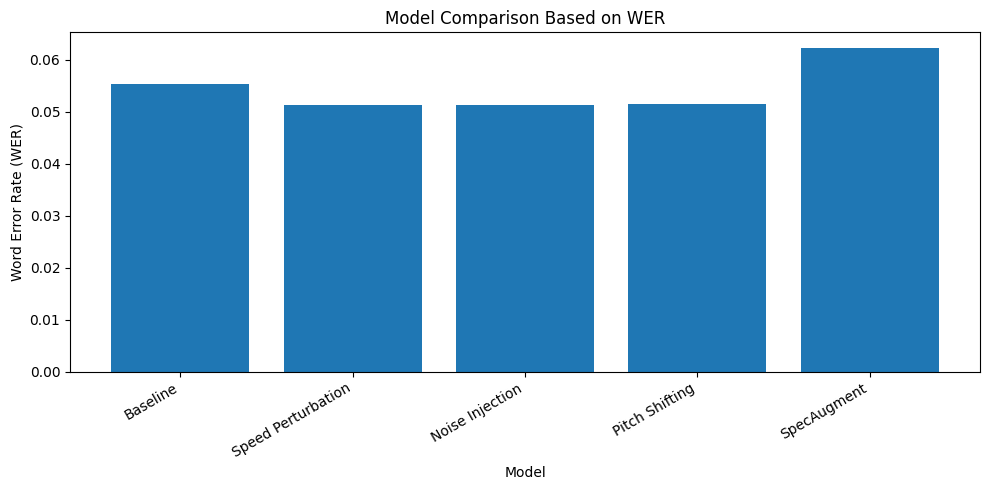

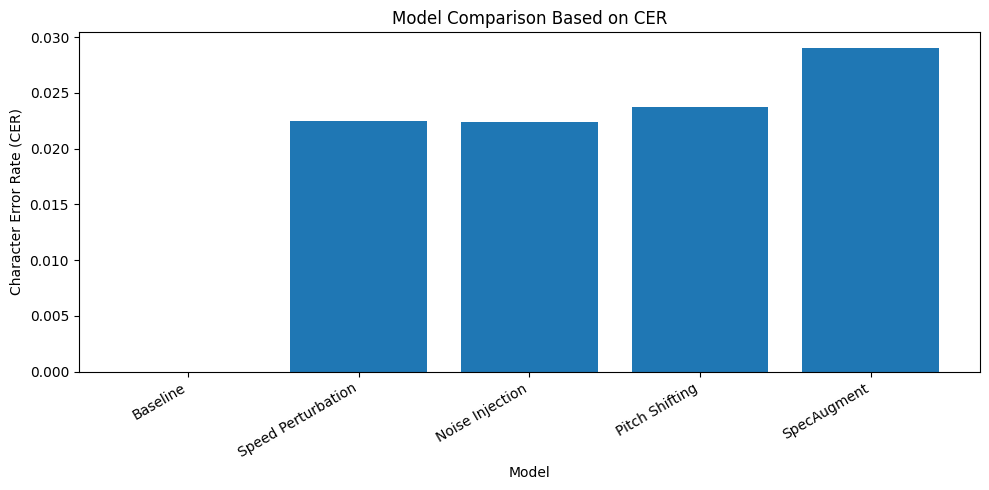

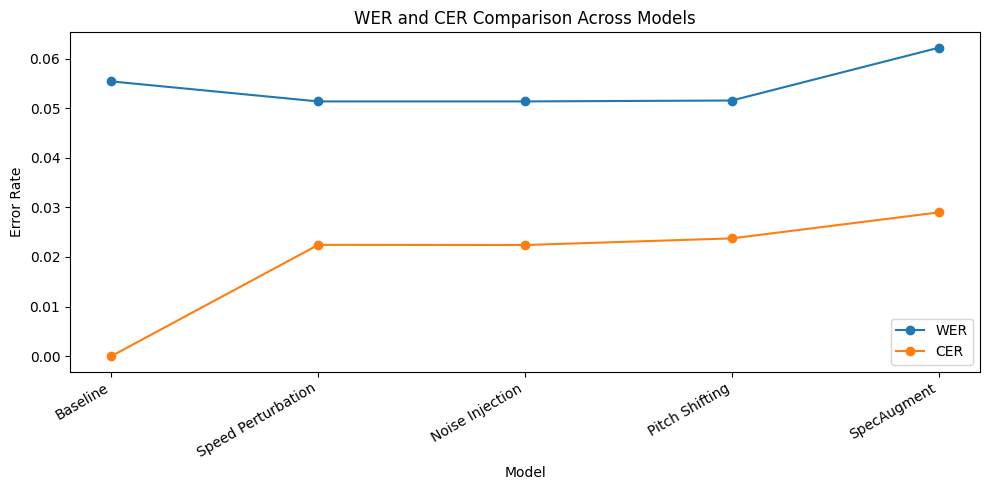

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Replace these values with your real WER and CER results
results = {
    "Model": [
        "Baseline",
        "Speed Perturbation",
        "Noise Injection",
        "Pitch Shifting",
        "SpecAugment"
    ],
    "WER": [0.055393, 0.051357, 0.051357, 0.051541, 0.062179],
    "CER": [0, 0.022434, 0.022398, 0.023743, 0.028980]
}

df = pd.DataFrame(results)

# =========================
# WER comparison
# =========================
plt.figure(figsize=(10, 5))
plt.bar(df["Model"], df["WER"])
plt.title("Model Comparison Based on WER")
plt.xlabel("Model")
plt.ylabel("Word Error Rate (WER)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

# =========================
# CER comparison
# =========================
plt.figure(figsize=(10, 5))
plt.bar(df["Model"], df["CER"])
plt.title("Model Comparison Based on CER")
plt.xlabel("Model")
plt.ylabel("Character Error Rate (CER)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

# =========================
# WER and CER line comparison
# =========================
plt.figure(figsize=(10, 5))
plt.plot(df["Model"], df["WER"], marker="o", label="WER")
plt.plot(df["Model"], df["CER"], marker="o", label="CER")
plt.title("WER and CER Comparison Across Models")
plt.xlabel("Model")
plt.ylabel("Error Rate")
plt.xticks(rotation=30, ha="right")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
!pip install -q transformers datasets evaluate jiwer accelerate soundfile

import torch
import pandas as pd
import evaluate

from dataclasses import dataclass
from typing import Any

from datasets import Dataset, Audio
from transformers import (
    WhisperProcessor,
    WhisperForConditionalGeneration,
    Seq2SeqTrainingArguments,
    Seq2SeqTrainer
)

# =========================================================
# GPU CHECK
# =========================================================

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

# =========================================================
# FILE PATHS
# =========================================================

train_csv = "/content/drive/MyDrive/spcs_whisper_project/manifests/train.csv"
valid_csv = "/content/drive/MyDrive/spcs_whisper_project/manifests/valid.csv"

# =========================================================
# LOAD DATA
# =========================================================

train_df = pd.read_csv(train_csv)
valid_df = pd.read_csv(valid_csv)

print("Training samples:", len(train_df))
print("Validation samples:", len(valid_df))

# =========================================================
# CONVERT TO DATASETS
# =========================================================

train_ds = Dataset.from_pandas(train_df)
valid_ds = Dataset.from_pandas(valid_df)

train_ds = train_ds.cast_column("audio", Audio(sampling_rate=16000))
valid_ds = valid_ds.cast_column("audio", Audio(sampling_rate=16000))

# =========================================================
# LOAD WHISPER MODEL
# =========================================================

model_name = "openai/whisper-small"

# No language="English" because this is code-switching
processor = WhisperProcessor.from_pretrained(
    model_name,
    task="transcribe"
)

model = WhisperForConditionalGeneration.from_pretrained(model_name)

# Important: use generation_config, not model.config
model.generation_config.forced_decoder_ids = None
model.generation_config.suppress_tokens = []
model.generation_config.language = None
model.generation_config.task = "transcribe"

model.to(device)

# =========================================================
# PREPARE DATASET
# =========================================================

def prepare_dataset(batch):
    audio = batch["audio"]

    batch["input_features"] = processor.feature_extractor(
        audio["array"],
        sampling_rate=audio["sampling_rate"]
    ).input_features[0]

    batch["labels"] = processor.tokenizer(
        batch["text"]
    ).input_ids

    return batch

train_ds = train_ds.map(
    prepare_dataset,
    remove_columns=train_ds.column_names,
    num_proc=1
)

valid_ds = valid_ds.map(
    prepare_dataset,
    remove_columns=valid_ds.column_names,
    num_proc=1
)

# =========================================================
# DATA COLLATOR
# =========================================================

@dataclass
class DataCollatorSpeechSeq2SeqWithPadding:
    processor: Any

    def __call__(self, features):
        input_features = [
            {"input_features": feature["input_features"]}
            for feature in features
        ]

        batch = self.processor.feature_extractor.pad(
            input_features,
            return_tensors="pt"
        )

        label_features = [
            {"input_ids": feature["labels"]}
            for feature in features
        ]

        labels_batch = self.processor.tokenizer.pad(
            label_features,
            return_tensors="pt"
        )

        labels = labels_batch["input_ids"].masked_fill(
            labels_batch.attention_mask.ne(1),
            -100
        )

        batch["labels"] = labels

        return batch

data_collator = DataCollatorSpeechSeq2SeqWithPadding(
    processor=processor
)

# =========================================================
# METRIC
# =========================================================

wer_metric = evaluate.load("wer")

def compute_metrics(pred):
    pred_ids = pred.predictions
    label_ids = pred.label_ids

    label_ids[label_ids == -100] = processor.tokenizer.pad_token_id

    pred_str = processor.tokenizer.batch_decode(
        pred_ids,
        skip_special_tokens=True
    )

    label_str = processor.tokenizer.batch_decode(
        label_ids,
        skip_special_tokens=True
    )

    wer = wer_metric.compute(
        predictions=pred_str,
        references=label_str
    )

    return {"wer": wer}

# =========================================================
# TRAINING ARGUMENTS
# =========================================================

training_args = Seq2SeqTrainingArguments(
    output_dir="/content/drive/MyDrive/spcs_whisper_project/models/exp1_codeswitch",

    per_device_train_batch_size=1,
    per_device_eval_batch_size=1,
    gradient_accumulation_steps=8,

    learning_rate=1e-5,
    num_train_epochs=3,

    fp16=True,
    gradient_checkpointing=True,

    eval_strategy="epoch",
    save_strategy="epoch",

    logging_steps=25,
    save_total_limit=2,

    predict_with_generate=True,
    generation_max_length=225,

    report_to="none"
)

# =========================================================
# TRAINER
# =========================================================

trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=valid_ds,
    data_collator=data_collator,
    processing_class=processor.feature_extractor,
    compute_metrics=compute_metrics
)

# =========================================================
# TRAIN
# =========================================================

trainer.train()

# =========================================================
# SAVE FINAL MODEL
# =========================================================

save_path = "/content/drive/MyDrive/spcs_whisper_project/models/final_whisper_small_codeswitch"

trainer.save_model(save_path)
processor.save_pretrained(save_path)

print("Training complete.")
print("Model saved to:", save_path)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 49.3 MB/s eta 0:00:00
Using device: cuda
Training samples: 9908
Validation samples: 1239


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

...

special_tokens_map.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/967M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/479 [00:00<?, ?it/s]

generation_config.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/9908 [00:00<?, ? examples/s]

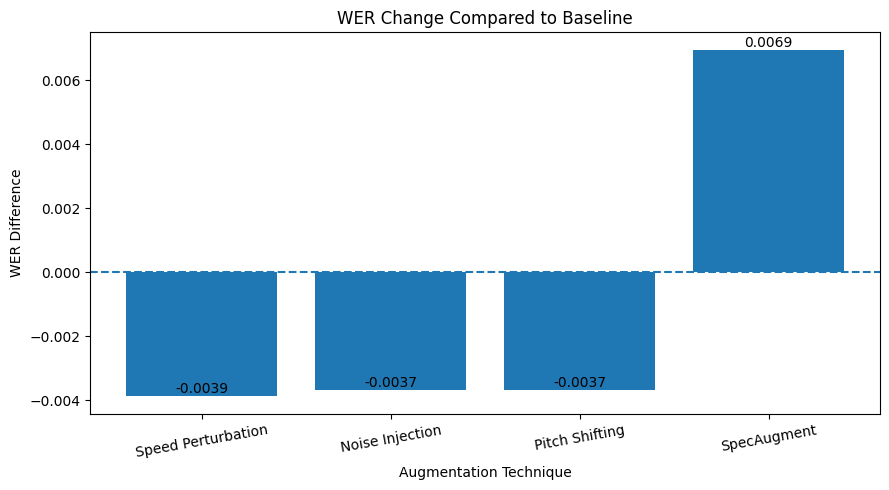

In [ ]:
import matplotlib.pyplot as plt

# WER results from your document
baseline = 0.055230

techniques = [
    "Speed Perturbation",
    "Noise Injection",
    "Pitch Shifting",
    "SpecAugment"
]

# WER values from the results
wer_values = [
    0.051357,
    0.051541,
    0.051541,
    0.062179
]

# Calculate change compared to baseline
wer_change = [value - baseline for value in wer_values]

# Create figure
plt.figure(figsize=(9,5))

# Create bar chart
bars = plt.bar(techniques, wer_change)

# Add horizontal reference line
plt.axhline(0, linestyle='--')

# Titles and labels
plt.title("WER Change Compared to Baseline")
plt.xlabel("Augmentation Technique")
plt.ylabel("WER Difference")

# Add value labels
for bar in bars:
    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{height:.4f}",
        ha='center',
        va='bottom'
    )

# Rotate labels slightly
plt.xticks(rotation=10)

# Improve spacing
plt.tight_layout()

# Show plot
plt.show()

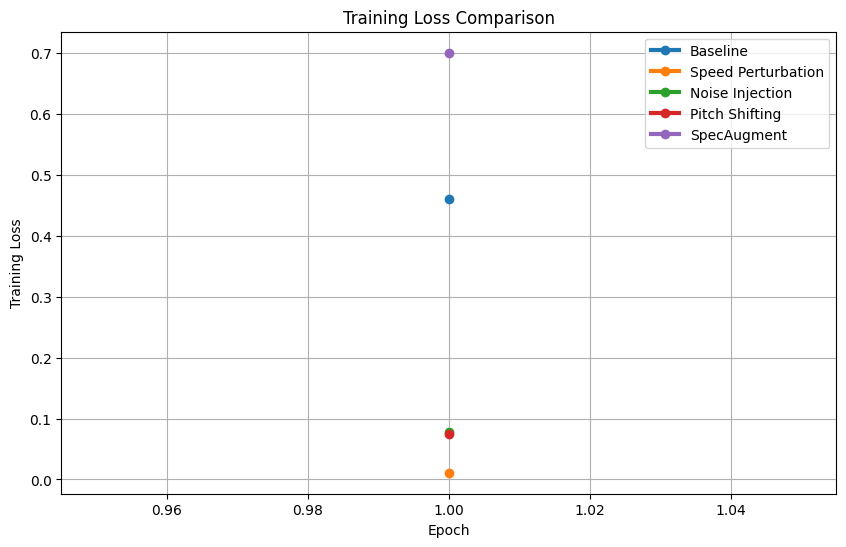

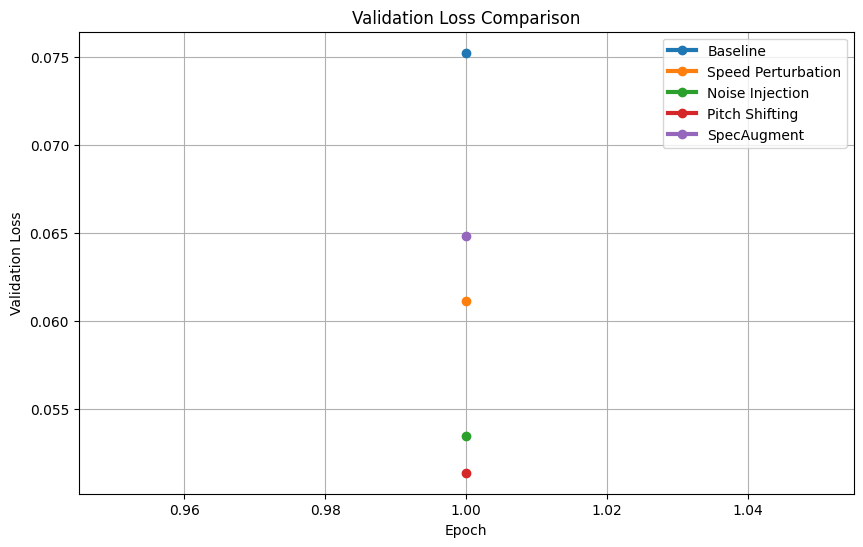

In [ ]:
# =========================================================
# LOSS COMPARISON GRAPHS
# USING YOUR REAL RESULTS
# =========================================================

import matplotlib.pyplot as plt

# Epochs
epochs = [1]

# ==============================
# TRAINING LOSS VALUES
# ==============================

baseline_train = [0.46077]
speed_train = [0.011072]
noise_train = [0.077803]
pitch_train = [0.073864]
spec_train = [0.70093]

# ==============================
# VALIDATION LOSS VALUES
# ==============================

baseline_val = [0.075250]
speed_val = [0.061123]
noise_val = [0.053494]
pitch_val = [0.051398]
spec_val = [0.064831]

# =========================================================
# GRAPH 1: TRAINING LOSS
# =========================================================

plt.figure(figsize=(10,6))

plt.plot(epochs, baseline_train, marker='o', linewidth=3, label='Baseline')
plt.plot(epochs, speed_train, marker='o', linewidth=3, label='Speed Perturbation')
plt.plot(epochs, noise_train, marker='o', linewidth=3, label='Noise Injection')
plt.plot(epochs, pitch_train, marker='o', linewidth=3, label='Pitch Shifting')
plt.plot(epochs, spec_train, marker='o', linewidth=3, label='SpecAugment')

plt.title("Training Loss Comparison")
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.legend()
plt.grid(True)

plt.show()

# =========================================================
# GRAPH 2: VALIDATION LOSS
# =========================================================

plt.figure(figsize=(10,6))

plt.plot(epochs, baseline_val, marker='o', linewidth=3, label='Baseline')
plt.plot(epochs, speed_val, marker='o', linewidth=3, label='Speed Perturbation')
plt.plot(epochs, noise_val, marker='o', linewidth=3, label='Noise Injection')
plt.plot(epochs, pitch_val, marker='o', linewidth=3, label='Pitch Shifting')
plt.plot(epochs, spec_val, marker='o', linewidth=3, label='SpecAugment')

plt.title("Validation Loss Comparison")
plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
!pip install -q transformers datasets evaluate jiwer accelerate soundfile

import torch
import pandas as pd
import evaluate

from dataclasses import dataclass
from typing import Any

from datasets import Dataset, Audio
from transformers import (
    WhisperProcessor,
    WhisperForConditionalGeneration,
    Seq2SeqTrainingArguments,
    Seq2SeqTrainer
)

# =========================================================
# GPU CHECK
# =========================================================

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

# =========================================================
# FILE PATHS
# =========================================================

train_csv = "/content/drive/MyDrive/spcs_whisper_project/manifests/train.csv"
valid_csv = "/content/drive/MyDrive/spcs_whisper_project/manifests/valid.csv"

# =========================================================
# LOAD DATA
# =========================================================

train_df = pd.read_csv(train_csv)
valid_df = pd.read_csv(valid_csv)

print("Training samples:", len(train_df))
print("Validation samples:", len(valid_df))

# =========================================================
# CONVERT TO DATASETS
# =========================================================

train_ds = Dataset.from_pandas(train_df)
valid_ds = Dataset.from_pandas(valid_df)

train_ds = train_ds.cast_column("audio", Audio(sampling_rate=16000))
valid_ds = valid_ds.cast_column("audio", Audio(sampling_rate=16000))

# =========================================================
# LOAD WHISPER MODEL
# =========================================================

model_name = "openai/whisper-small"

# No language="English" because this is code-switching
processor = WhisperProcessor.from_pretrained(
    model_name,
    task="transcribe"
)

model = WhisperForConditionalGeneration.from_pretrained(model_name)

# Important: use generation_config, not model.config
model.generation_config.forced_decoder_ids = None
model.generation_config.suppress_tokens = []
model.generation_config.language = None
model.generation_config.task = "transcribe"

model.to(device)

# =========================================================
# PREPARE DATASET
# =========================================================

def prepare_dataset(batch):
    audio = batch["audio"]

    batch["input_features"] = processor.feature_extractor(
        audio["array"],
        sampling_rate=audio["sampling_rate"]
    ).input_features[0]

    batch["labels"] = processor.tokenizer(
        batch["text"]
    ).input_ids

    return batch

train_ds = train_ds.map(
    prepare_dataset,
    remove_columns=train_ds.column_names,
    num_proc=1
)

valid_ds = valid_ds.map(
    prepare_dataset,
    remove_columns=valid_ds.column_names,
    num_proc=1
)

# =========================================================
# DATA COLLATOR
# =========================================================

@dataclass
class DataCollatorSpeechSeq2SeqWithPadding:
    processor: Any

    def __call__(self, features):
        input_features = [
            {"input_features": feature["input_features"]}
            for feature in features
        ]

        batch = self.processor.feature_extractor.pad(
            input_features,
            return_tensors="pt"
        )

        label_features = [
            {"input_ids": feature["labels"]}
            for feature in features
        ]

        labels_batch = self.processor.tokenizer.pad(
            label_features,
            return_tensors="pt"
        )

        labels = labels_batch["input_ids"].masked_fill(
            labels_batch.attention_mask.ne(1),
            -100
        )

        batch["labels"] = labels

        return batch

data_collator = DataCollatorSpeechSeq2SeqWithPadding(
    processor=processor
)

# =========================================================
# METRIC
# =========================================================

wer_metric = evaluate.load("wer")

def compute_metrics(pred):
    pred_ids = pred.predictions
    label_ids = pred.label_ids

    label_ids[label_ids == -100] = processor.tokenizer.pad_token_id

    pred_str = processor.tokenizer.batch_decode(
        pred_ids,
        skip_special_tokens=True
    )

    label_str = processor.tokenizer.batch_decode(
        label_ids,
        skip_special_tokens=True
    )

    wer = wer_metric.compute(
        predictions=pred_str,
        references=label_str
    )

    return {"wer": wer}

# =========================================================
# TRAINING ARGUMENTS
# =========================================================

training_args = Seq2SeqTrainingArguments(
    output_dir="/content/drive/MyDrive/spcs_whisper_project/models/exp1_codeswitch",

    per_device_train_batch_size=1,
    per_device_eval_batch_size=1,
    gradient_accumulation_steps=8,

    learning_rate=1e-5,
    num_train_epochs=1,

    fp16=True,
    gradient_checkpointing=True,

    eval_strategy="epoch",
    save_strategy="epoch",

    logging_steps=25,
    save_total_limit=2,

    predict_with_generate=True,
    generation_max_length=225,

    report_to="none"
)

# =========================================================
# TRAINER
# =========================================================

trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=valid_ds,
    data_collator=data_collator,
    processing_class=processor.feature_extractor,
    compute_metrics=compute_metrics
)

# =========================================================
# TRAIN
# =========================================================

trainer.train()

# =========================================================
# SAVE FINAL MODEL
# =========================================================

save_path = "/content/drive/MyDrive/spcs_whisper_project/models/final_whisper_small_codeswitch"

trainer.save_model(save_path)
processor.save_pretrained(save_path)

print("Training complete.")
print("Model saved to:", save_path)

testing with 10 ecpochs

In [ ]:
!pip install -q transformers datasets evaluate jiwer accelerate soundfile

import torch
import pandas as pd
import evaluate

from dataclasses import dataclass
from typing import Any

from datasets import Dataset, Audio
from transformers import (
    WhisperProcessor,
    WhisperForConditionalGeneration,
    Seq2SeqTrainingArguments,
    Seq2SeqTrainer
)

# =========================================================
# GPU CHECK
# =========================================================

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

# =========================================================
# FILE PATHS
# =========================================================

train_csv = "/content/drive/MyDrive/spcs_whisper_project/manifests/train.csv"
valid_csv = "/content/drive/MyDrive/spcs_whisper_project/manifests/valid.csv"

# =========================================================
# LOAD DATA
# =========================================================

train_df = pd.read_csv(train_csv)
valid_df = pd.read_csv(valid_csv)

print("Training samples:", len(train_df))
print("Validation samples:", len(valid_df))

# =========================================================
# CONVERT TO DATASETS
# =========================================================

train_ds = Dataset.from_pandas(train_df)
valid_ds = Dataset.from_pandas(valid_df)

train_ds = train_ds.cast_column("audio", Audio(sampling_rate=16000))
valid_ds = valid_ds.cast_column("audio", Audio(sampling_rate=16000))

# =========================================================
# LOAD WHISPER MODEL
# =========================================================

model_name = "openai/whisper-small"

# No language="English" because this is code-switching
processor = WhisperProcessor.from_pretrained(
    model_name,
    task="transcribe"
)

model = WhisperForConditionalGeneration.from_pretrained(model_name)

# Important: use generation_config, not model.config
model.generation_config.forced_decoder_ids = None
model.generation_config.suppress_tokens = []
model.generation_config.language = None
model.generation_config.task = "transcribe"

model.to(device)

# =========================================================
# PREPARE DATASET
# =========================================================

def prepare_dataset(batch):
    audio = batch["audio"]

    batch["input_features"] = processor.feature_extractor(
        audio["array"],
        sampling_rate=audio["sampling_rate"]
    ).input_features[0]

    batch["labels"] = processor.tokenizer(
        batch["text"]
    ).input_ids

    return batch

train_ds = train_ds.map(
    prepare_dataset,
    remove_columns=train_ds.column_names,
    num_proc=1
)

valid_ds = valid_ds.map(
    prepare_dataset,
    remove_columns=valid_ds.column_names,
    num_proc=1
)

# =========================================================
# DATA COLLATOR
# =========================================================

@dataclass
class DataCollatorSpeechSeq2SeqWithPadding:
    processor: Any

    def __call__(self, features):
        input_features = [
            {"input_features": feature["input_features"]}
            for feature in features
        ]

        batch = self.processor.feature_extractor.pad(
            input_features,
            return_tensors="pt"
        )

        label_features = [
            {"input_ids": feature["labels"]}
            for feature in features
        ]

        labels_batch = self.processor.tokenizer.pad(
            label_features,
            return_tensors="pt"
        )

        labels = labels_batch["input_ids"].masked_fill(
            labels_batch.attention_mask.ne(1),
            -100
        )

        batch["labels"] = labels

        return batch

data_collator = DataCollatorSpeechSeq2SeqWithPadding(
    processor=processor
)

# =========================================================
# METRIC
# =========================================================

wer_metric = evaluate.load("wer")

def compute_metrics(pred):
    pred_ids = pred.predictions
    label_ids = pred.label_ids

    label_ids[label_ids == -100] = processor.tokenizer.pad_token_id

    pred_str = processor.tokenizer.batch_decode(
        pred_ids,
        skip_special_tokens=True
    )

    label_str = processor.tokenizer.batch_decode(
        label_ids,
        skip_special_tokens=True
    )

    wer = wer_metric.compute(
        predictions=pred_str,
        references=label_str
    )

    return {"wer": wer}

# =========================================================
# TRAINING ARGUMENTS
# =========================================================

training_args = Seq2SeqTrainingArguments(
    output_dir="/content/drive/MyDrive/spcs_whisper_project/models/exp1_codeswitch",

    per_device_train_batch_size=1,
    per_device_eval_batch_size=1,
    gradient_accumulation_steps=8,

    learning_rate=1e-5,
    num_train_epochs=10,

    fp16=True,
    gradient_checkpointing=True,

    eval_strategy="epoch",
    save_strategy="epoch",

    logging_steps=25,
    save_total_limit=2,

    predict_with_generate=True,
    generation_max_length=225,

    report_to="none"
)

# =========================================================
# TRAINER
# =========================================================

trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=valid_ds,
    data_collator=data_collator,
    processing_class=processor.feature_extractor,
    compute_metrics=compute_metrics
)

# =========================================================
# TRAIN
# =========================================================

trainer.train()

# =========================================================
# SAVE FINAL MODEL
# =========================================================

save_path = "/content/drive/MyDrive/spcs_whisper_project/models/final_whisper_small_baseline"

trainer.save_model(save_path)
processor.save_pretrained(save_path)

print("Training complete.")
print("Model saved to:", save_path)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 53.2 MB/s eta 0:00:00
Using device: cuda
Training samples: 9908
Validation samples: 1239


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/185k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.97k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/283k [00:00<?, ?B/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [ ]:
!ls /content/drive/MyDrive/spcs_whisper_project/models/exp1_codeswitch


checkpoint-6195  checkpoint-7434


In [ ]:
import json

with open(
    "/content/drive/MyDrive/spcs_whisper_project/models/exp1_codeswitch/checkpoint-7434/trainer_state.json"
) as f:
    state = json.load(f)

print("Epoch:", state["epoch"])
print("Global step:", state["global_step"])

Epoch: 6.0
Global step: 7434


In [ ]:
!pip install -q transformers datasets evaluate jiwer accelerate soundfile

import torch
import pandas as pd
import evaluate

from dataclasses import dataclass
from typing import Any

from datasets import Dataset, Audio
from transformers import (
    WhisperProcessor,
    WhisperForConditionalGeneration,
    Seq2SeqTrainingArguments,
    Seq2SeqTrainer
)

# =========================================================
# GPU CHECK
# =========================================================

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

# =========================================================
# FILE PATHS
# =========================================================

train_csv = "/content/drive/MyDrive/spcs_whisper_project/manifests/train.csv"
valid_csv = "/content/drive/MyDrive/spcs_whisper_project/manifests/valid.csv"

# =========================================================
# LOAD DATA
# =========================================================

train_df = pd.read_csv(train_csv)
valid_df = pd.read_csv(valid_csv)

print("Training samples:", len(train_df))
print("Validation samples:", len(valid_df))

# =========================================================
# CONVERT TO DATASETS
# =========================================================

train_ds = Dataset.from_pandas(train_df)
valid_ds = Dataset.from_pandas(valid_df)

train_ds = train_ds.cast_column("audio", Audio(sampling_rate=16000))
valid_ds = valid_ds.cast_column("audio", Audio(sampling_rate=16000))

# =========================================================
# LOAD WHISPER MODEL
# =========================================================

model_name = "openai/whisper-small"

# No language="English" because this is code-switching
processor = WhisperProcessor.from_pretrained(
    model_name,
    task="transcribe"
)

model = WhisperForConditionalGeneration.from_pretrained(model_name)

# Important: use generation_config, not model.config
model.generation_config.forced_decoder_ids = None
model.generation_config.suppress_tokens = []
model.generation_config.language = None
model.generation_config.task = "transcribe"

model.to(device)

# =========================================================
# PREPARE DATASET
# =========================================================

def prepare_dataset(batch):
    audio = batch["audio"]

    batch["input_features"] = processor.feature_extractor(
        audio["array"],
        sampling_rate=audio["sampling_rate"]
    ).input_features[0]

    batch["labels"] = processor.tokenizer(
        batch["text"]
    ).input_ids

    return batch

train_ds = train_ds.map(
    prepare_dataset,
    remove_columns=train_ds.column_names,
    num_proc=1
)

valid_ds = valid_ds.map(
    prepare_dataset,
    remove_columns=valid_ds.column_names,
    num_proc=1
)

# =========================================================
# DATA COLLATOR
# =========================================================

@dataclass
class DataCollatorSpeechSeq2SeqWithPadding:
    processor: Any

    def __call__(self, features):
        input_features = [
            {"input_features": feature["input_features"]}
            for feature in features
        ]

        batch = self.processor.feature_extractor.pad(
            input_features,
            return_tensors="pt"
        )

        label_features = [
            {"input_ids": feature["labels"]}
            for feature in features
        ]

        labels_batch = self.processor.tokenizer.pad(
            label_features,
            return_tensors="pt"
        )

        labels = labels_batch["input_ids"].masked_fill(
            labels_batch.attention_mask.ne(1),
            -100
        )

        batch["labels"] = labels

        return batch

data_collator = DataCollatorSpeechSeq2SeqWithPadding(
    processor=processor
)

# =========================================================
# METRIC
# =========================================================

wer_metric = evaluate.load("wer")

def compute_metrics(pred):
    pred_ids = pred.predictions
    label_ids = pred.label_ids

    label_ids[label_ids == -100] = processor.tokenizer.pad_token_id

    pred_str = processor.tokenizer.batch_decode(
        pred_ids,
        skip_special_tokens=True
    )

    label_str = processor.tokenizer.batch_decode(
        label_ids,
        skip_special_tokens=True
    )

    wer = wer_metric.compute(
        predictions=pred_str,
        references=label_str
    )

    return {"wer": wer}

# =========================================================
# TRAINING ARGUMENTS
# =========================================================

training_args = Seq2SeqTrainingArguments(
    output_dir="/content/drive/MyDrive/spcs_whisper_project/models/exp1_codeswitch",

    per_device_train_batch_size=1,
    per_device_eval_batch_size=1,
    gradient_accumulation_steps=8,

    learning_rate=1e-5,
    num_train_epochs=10,

    fp16=True,
    gradient_checkpointing=True,

    eval_strategy="epoch",
    save_strategy="epoch",

    logging_steps=25,
    save_total_limit=2,

    predict_with_generate=True,
    generation_max_length=225,

    report_to="none"
)

# =========================================================
# TRAINER
# =========================================================

trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=valid_ds,
    data_collator=data_collator,
    processing_class=processor.feature_extractor,
    compute_metrics=compute_metrics
)

# =========================================================
# TRAIN
# =========================================================

trainer.train(
    resume_from_checkpoint="/content/drive/MyDrive/spcs_whisper_project/models/exp1_codeswitch/checkpoint-7434"
)

# =========================================================
# SAVE FINAL MODEL
# =========================================================

save_path = "/content/drive/MyDrive/spcs_whisper_project/models/final_whisper_small_baseline"

trainer.save_model(save_path)
processor.save_pretrained(save_path)

print("Training complete.")
print("Model saved to:", save_path)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 50.0 MB/s eta 0:00:00
Using device: cuda
Training samples: 9908
Validation samples: 1239


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/185k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.97k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/283k [00:00<?, ?B/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Training complete.
Model saved to: /content/drive/MyDrive/spcs_whisper_project/models/final_whisper_small_baseline


In [ ]:
import pandas as pd

# =========================================================
# FILE PATHS
# =========================================================

train_csv = "/content/drive/MyDrive/spcs_whisper_project/manifests/train.csv"
valid_csv = "/content/drive/MyDrive/spcs_whisper_project/manifests/valid.csv"

# =========================================================
# LOAD CSV FILES
# =========================================================

train_df = pd.read_csv(train_csv)
valid_df = pd.read_csv(valid_csv)

print("=" * 60)
print("TRAIN SHAPE:", train_df.shape)
print("VALID SHAPE:", valid_df.shape)
print("=" * 60)

print("\nTrain columns:")
print(train_df.columns.tolist())

print("\nValid columns:")
print(valid_df.columns.tolist())

# =========================================================
# CHECK AUDIO FILE LEAKAGE
# =========================================================

if "audio" in train_df.columns and "audio" in valid_df.columns:

    train_audio = set(train_df["audio"])
    valid_audio = set(valid_df["audio"])

    audio_overlap = train_audio.intersection(valid_audio)

    print("\n" + "=" * 60)
    print("AUDIO FILE LEAKAGE CHECK")
    print("=" * 60)

    print("Train audio files:", len(train_audio))
    print("Valid audio files:", len(valid_audio))
    print("Overlapping audio files:", len(audio_overlap))

    if len(audio_overlap) > 0:
        print("\nFirst 10 overlapping files:")
        for f in list(audio_overlap)[:10]:
            print(f)

# =========================================================
# CHECK TRANSCRIPT LEAKAGE
# =========================================================

if "text" in train_df.columns and "text" in valid_df.columns:

    train_text = set(
        train_df["text"].astype(str).str.strip().str.lower()
    )

    valid_text = set(
        valid_df["text"].astype(str).str.strip().str.lower()
    )

    text_overlap = train_text.intersection(valid_text)

    print("\n" + "=" * 60)
    print("TRANSCRIPT LEAKAGE CHECK")
    print("=" * 60)

    print("Unique train transcripts:", len(train_text))
    print("Unique valid transcripts:", len(valid_text))
    print("Shared transcripts:", len(text_overlap))

    overlap_percent = (
        len(text_overlap) / len(valid_text) * 100
    )

    print(f"Transcript overlap: {overlap_percent:.2f}%")

# =========================================================
# CHECK EXACT DUPLICATES
# =========================================================

if "audio" in train_df.columns and "text" in train_df.columns:

    duplicates = pd.merge(
        train_df,
        valid_df,
        on=["audio", "text"],
        how="inner"
    )

    print("\n" + "=" * 60)
    print("EXACT DUPLICATE CHECK")
    print("=" * 60)

    print("Exact duplicate samples:", len(duplicates))

# =========================================================
# CHECK DUPLICATES INSIDE EACH SPLIT
# =========================================================

print("\n" + "=" * 60)
print("INTERNAL DUPLICATES")
print("=" * 60)

print(
    "Duplicate rows in train:",
    train_df.duplicated().sum()
)

print(
    "Duplicate rows in valid:",
    valid_df.duplicated().sum()
)

# =========================================================
# SUMMARY
# =========================================================

print("\n" + "=" * 60)
print("LEAKAGE CHECK COMPLETE")
print("=" * 60)

TRAIN SHAPE: (9908, 2)
VALID SHAPE: (1239, 2)

Train columns:
['audio', 'text']

Valid columns:
['audio', 'text']

AUDIO FILE LEAKAGE CHECK
Train audio files: 9908
Valid audio files: 1239
Overlapping audio files: 0

TRANSCRIPT LEAKAGE CHECK
Unique train transcripts: 449
Unique valid transcripts: 420
Shared transcripts: 420
Transcript overlap: 100.00%

EXACT DUPLICATE CHECK
Exact duplicate samples: 0

INTERNAL DUPLICATES
Duplicate rows in train: 0
Duplicate rows in valid: 0

LEAKAGE CHECK COMPLETE


In [ ]:
# =========================================================
# COMPARE ACTUAL VS PREDICTED TRANSCRIPTS
# =========================================================

import torch
import pandas as pd
from datasets import Dataset, Audio
from transformers import WhisperProcessor, WhisperForConditionalGeneration

# =========================================================
# DEVICE
# =========================================================

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

# =========================================================
# PATHS
# =========================================================

valid_csv = "/content/drive/MyDrive/spcs_whisper_project/manifests/valid.csv"

model_path = "/content/drive/MyDrive/spcs_whisper_project/models/final_whisper_small_baseline"

# =========================================================
# LOAD VALIDATION DATA
# =========================================================

valid_df = pd.read_csv(valid_csv)

print("Validation samples:", len(valid_df))

# =========================================================
# LOAD MODEL
# =========================================================

processor = WhisperProcessor.from_pretrained(model_path)

model = WhisperForConditionalGeneration.from_pretrained(model_path)

model.to(device)
model.eval()

# =========================================================
# CREATE DATASET
# =========================================================

valid_ds = Dataset.from_pandas(valid_df)

valid_ds = valid_ds.cast_column(
    "audio",
    Audio(sampling_rate=16000)
)

# =========================================================
# GENERATE PREDICTIONS
# =========================================================

results = []

num_samples = min(50, len(valid_ds))  # change if needed

for i in range(num_samples):

    sample = valid_ds[i]

    audio = sample["audio"]

    input_features = processor.feature_extractor(
        audio["array"],
        sampling_rate=audio["sampling_rate"],
        return_tensors="pt"
    ).input_features.to(device)

    with torch.no_grad():

        predicted_ids = model.generate(
            input_features,
            max_length=225
        )

    prediction = processor.tokenizer.decode(
        predicted_ids[0],
        skip_special_tokens=True
    ).strip()

    actual = sample["text"].strip()

    results.append({
        "sample": i,
        "actual": actual,
        "predicted": prediction,
        "correct": actual.lower() == prediction.lower()
    })

    print("=" * 100)
    print(f"Sample {i}")
    print("ACTUAL   :", actual)
    print("PREDICTED:", prediction)
    print("MATCH    :", actual.lower() == prediction.lower())

# =========================================================
# SAVE RESULTS
# =========================================================

results_df = pd.DataFrame(results)

results_df.to_csv(
    "/content/drive/MyDrive/spcs_whisper_project/prediction_comparison.csv",
    index=False
)

print("\nSaved to prediction_comparison.csv")

# =========================================================
# SHOW MISTAKES ONLY
# =========================================================

mistakes = results_df[results_df["correct"] == False]

print("\nTotal mistakes:", len(mistakes))

if len(mistakes) > 0:
    print("\nFirst mistakes:")
    print(mistakes[["actual", "predicted"]].head(20))

Using device: cuda
Validation samples: 1239


Loading weights:   0%|          | 0/479 [00:00<?, ?it/s]

[transformers] The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
[transformers] A custom logits processor of type <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> has been passed to `.generate()`, but it was also created in `.generate()`, given its parameterization. The custom <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> will take precedence. Please check the docstring of <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> to see related `.generate()` flags.
[transformers] A custom logits processor of type <class 'transformers.generation.logits_process.SuppressTokensAtBeginLogitsProcessor'> has been passed to `.generate()`, but it was also created in `.generate()`, given its parameterization. The custom <class 'transform

Sample 0
ACTUAL   : kare ke fashion ye nngwe
PREDICTED: kare ke fashion ye nngwe
MATCH    : True
Sample 1
ACTUAL   : okay ke a leboga
PREDICTED: okay ke a leboga
MATCH    : True
Sample 2
ACTUAL   : di ofisi tša rena magaeng
PREDICTED: ofisi tša rena magaeng
MATCH    : False
Sample 3
ACTUAL   : mmušo wa rena wa democracy
PREDICTED: mmušo wa rena wa democracy
MATCH    : True
Sample 4
ACTUAL   : e be agency fela
PREDICTED: e be agency fela
MATCH    : True
Sample 5
ACTUAL   : who are leading the right
PREDICTED: who are leading the right
MATCH    : True
Sample 6
ACTUAL   : holong ya masepala
PREDICTED: holong ya masepala
MATCH    : True
Sample 7
ACTUAL   : tšona di skills
PREDICTED: tšona di skills
MATCH    : True
Sample 8
ACTUAL   : companying a tee
PREDICTED: companying a tee
MATCH    : True
Sample 9
ACTUAL   : dinatla tša mmino wa gospel
PREDICTED: dinatla tša mmino wa gospel
MATCH    : True
Sample 10
ACTUAL   : go tla interview
PREDICTED: go tla interview
MATCH    : True
Sample 11
ACTU

In [ ]:
# =========================================================
# EVALUATE ALL VALIDATION SAMPLES
# =========================================================

import torch
import pandas as pd
from datasets import Dataset, Audio
from transformers import WhisperProcessor, WhisperForConditionalGeneration
from tqdm import tqdm

# =========================================================
# DEVICE
# =========================================================

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

# =========================================================
# PATHS
# =========================================================

valid_csv = "/content/drive/MyDrive/spcs_whisper_project/manifests/valid.csv"

model_path = "/content/drive/MyDrive/spcs_whisper_project/models/final_whisper_small_baseline"

output_csv = "/content/drive/MyDrive/spcs_whisper_project/all_predictions.csv"

# =========================================================
# LOAD DATA
# =========================================================

valid_df = pd.read_csv(valid_csv)

print("Validation samples:", len(valid_df))

# =========================================================
# LOAD MODEL
# =========================================================

processor = WhisperProcessor.from_pretrained(model_path)

model = WhisperForConditionalGeneration.from_pretrained(model_path)

model.to(device)
model.eval()

# =========================================================
# DATASET
# =========================================================

valid_ds = Dataset.from_pandas(valid_df)

valid_ds = valid_ds.cast_column(
    "audio",
    Audio(sampling_rate=16000)
)

# =========================================================
# PREDICT ALL SAMPLES
# =========================================================

results = []

for i in tqdm(range(len(valid_ds))):

    sample = valid_ds[i]

    audio = sample["audio"]

    input_features = processor.feature_extractor(
        audio["array"],
        sampling_rate=audio["sampling_rate"],
        return_tensors="pt"
    ).input_features.to(device)

    with torch.no_grad():

        predicted_ids = model.generate(
            input_features,
            max_length=225
        )

    prediction = processor.tokenizer.decode(
        predicted_ids[0],
        skip_special_tokens=True
    ).strip()

    actual = str(sample["text"]).strip()

    results.append({
        "sample_id": i,
        "actual": actual,
        "predicted": prediction,
        "match": actual.lower() == prediction.lower()
    })

# =========================================================
# SAVE RESULTS
# =========================================================

results_df = pd.DataFrame(results)

results_df.to_csv(output_csv, index=False)

print("\nSaved results to:")
print(output_csv)

# =========================================================
# SUMMARY
# =========================================================

total = len(results_df)
correct = results_df["match"].sum()
incorrect = total - correct

print("\n==============================")
print("SUMMARY")
print("==============================")
print("Total samples :", total)
print("Correct       :", correct)
print("Incorrect     :", incorrect)
print("Accuracy      :", round(correct / total * 100, 2), "%")

# =========================================================
# SHOW FIRST 20 ERRORS
# =========================================================

errors = results_df[results_df["match"] == False]

print("\nTotal Errors:", len(errors))

if len(errors) > 0:
    print("\nFirst 20 Errors:")
    print(errors[["actual", "predicted"]].head(20))

Using device: cuda
Validation samples: 1239


Loading weights:   0%|          | 0/479 [00:00<?, ?it/s]

100%|██████████| 1239/1239 [19:56<00:00,  1.04it/s]


Saved results to:
/content/drive/MyDrive/spcs_whisper_project/all_predictions.csv

SUMMARY
Total samples : 1239
Correct       : 1172
Incorrect     : 67
Accuracy      : 94.59 %

Total Errors: 67

First 20 Errors:
                                actual                        predicted
2            di ofisi tša rena magaeng           ofisi tša rena magaeng
34        hweditše di report tše botse     hweditse di report tse botse
39                  ge go nyakega copy               ka go nyakega copy
58           ke goletše mo lekeišeneng        ko goletše mo lekeišeneng
68     la tharo december twenty eleven         la tharo december eleven
72       e tšhaba tšhaba mo networkeng           e tšhaba mo networkeng
161  labohlano la di eighteen november   labohlano la di eight november
165               ke a ratang a bibele               ke ratang a bibele
210                  ba tšea ke camera                   ba tšea camera
266               ke a ratang a bibele             ke a ratang a bi